In [ ]:
# MODELLO 5: niente recettori ma osmosi si.
# Faccio il fit considerando anche i valori della membrana. La membrana è costante, ma il modello non descrive i dati cellulari in maniera opportuna! Forse bisogna aggiungere numero di cellule nel termine di Am


import numpy as np
from scipy.integrate import solve_ivp
from scipy.optimize import least_squares
import matplotlib.pyplot as plt
import pandas as pd

# Impostazione dello stile grafico
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

In [112]:
# --- PARAMETRI FISICI ---
# Radionuclide di esempio: Lutezio-177 (177Lu)
T_half = 160.8  # Emivita fisica in ore (~6.7 giorni)
lmbda = np.log(2) / T_half  # Costante di decadimento fisico (h^-1)

# --- PARAMETRI ---
k0 = 0      # Costante dissociazione (h^-1) -> k-1
k1 = 0    # Costante di associazione (h^-1) -> cR*k1 negli appunti
k2 = 0      # Costante di internalizzazione tramite proteine (h^-1)
k3 = 0.1     # Costante di internalizzazione tramite osmosi (h^-1)

# --- PARAMETRI DELLA COLTURA ---
A0 = 25000       # Attività iniziale iniettata nel terreno di coltura (kBq)
A0_mem = 0.05e-3    # Attività iniziale membrana in kBq

def cellular_kinetic_system(t, y, lmbda, k0, k1, k2, k3):
    """
    Sistema ODE per la cinetica del radiofarmaco in vitro.
    y = [Am, Ab, Aint]
    """
    Am, Ab, Aint, Adec = y

    # Equazioni differenziali del sistema
    dAm_dt = k0 * Ab - (lmbda + k3) * Am - k1 * Am
    dAb_dt = k1 * Am - (lmbda + k0 + k2) * Ab
    dAint_dt = -lmbda * Aint + k2 * Ab + k3 * Am
    dAdec_dt = lmbda * (Am + Ab + Aint)
    
    return [dAm_dt, dAb_dt, dAint_dt, dAdec_dt]

# Condizioni iniziali: tutta l'attivita e inizialmente nel terreno Am(0) = A0
y0 = [A0, A0_mem, 0.0, 0.0]

# Intervallo temporale di simulazione (es. 72 ore)
t_span = (0, 4)
t_eval = np.linspace(t_span[0], t_span[1], 1000)

# Risoluzione del sistema ODE (metodo RK45)
sol = solve_ivp(
    cellular_kinetic_system, 
    t_span, 
    y0, 
    t_eval=t_eval, 
    args=(lmbda, k0, k1, k2, k3),
    method='RK45'
)

# Estrazione dei risultati
t = sol.t
Am, Ab, Aint, Adec = sol.y
A_cell_total = (Ab + Aint)*1000 # Attività totale accumulata dalla cellula (membrana + internalizzata)
A_tot = Am + Ab + Aint + Adec

# Calcolo dell'Attività Cumulata A_tilde (integrale dell'attività nel tempo)
cumulated_activity_cell = np.trapezoid(A_cell_total, t)  # in kBq*h

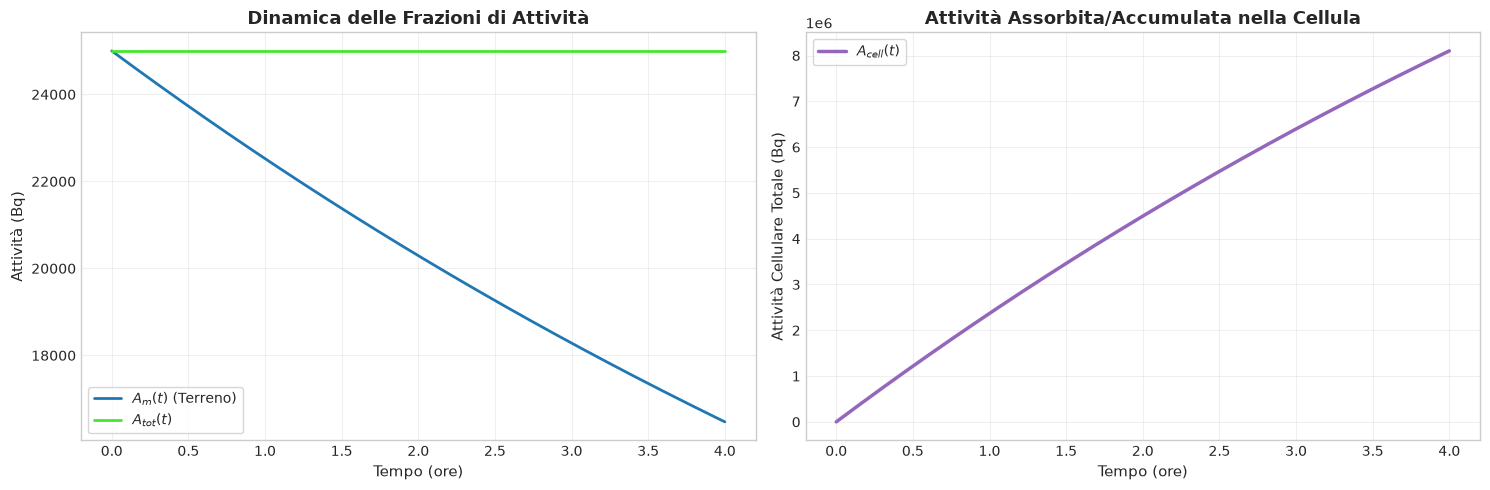

--------------------------------------------------
Attività Cumulata Cellulare Integrata (0-4h): 17382591.42 kBq·h
--------------------------------------------------


In [113]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Grafico 1: Cinetica nei tre compartimenti
axes[0].plot(t, Am, label='$A_m(t)$ (Terreno)', color='#1f77b4', linewidth=2)
axes[0].plot(t, A_tot, label='$A_{tot}(t)$', color="#45e72f", linewidth=2)
axes[0].set_xlabel('Tempo (ore)', fontsize=11)
axes[0].set_ylabel('Attività (Bq)', fontsize=11)
axes[0].set_title('Dinamica delle Frazioni di Attività', fontsize=13, fontweight='bold')
axes[0].legend(frameon=True)
axes[0].grid(True, alpha=0.3)

# Grafico 2: Attività Totale Cellulare e Saturazione
axes[1].plot(t, A_cell_total, label='$A_{cell}(t)$', color='#9467bd', linewidth=2.5)
axes[1].set_xlabel('Tempo (ore)', fontsize=11)
axes[1].set_ylabel('Attività Cellulare Totale (Bq)', fontsize=11)
axes[1].set_title('Attività Assorbita/Accumulata nella Cellula', fontsize=13, fontweight='bold')
axes[1].legend(frameon=True)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Stampa dell'attività cumulata
print(f"--------------------------------------------------")
print(f"Attività Cumulata Cellulare Integrata (0-{t_span[1]}h): {cumulated_activity_cell:.2f} kBq·h")
print(f"--------------------------------------------------")

    RISULTATI FIT SIMULTANEO (TOTALE + MEMBRANA)  
A0_mem_f (Attività iniziale sulla membrana) : 4.524733e-02 ± 1.709840e-03 h^-1
k3_f (Int. Osmotica)       : 1.431910e-05 ± 1.592932e-06 h^-1
--------------------------------------------------
Punti Totali Fit           : 32 (16 tot + 16 mem)
Chi-quadro Totale (Chi2)   : 216.2702
Gradi di libertà (dof)     : 30
Chi-quadro Ridotto         : 7.2090


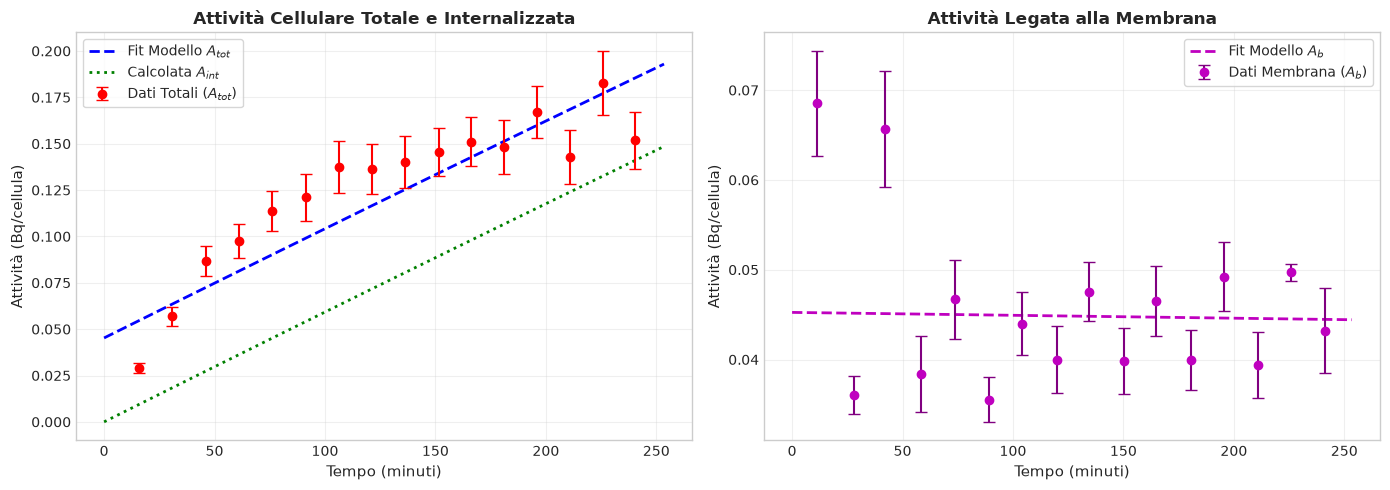

In [104]:
# =============================================================================
# 1. CARICAMENTO DEI 4 FILE CSV
# =============================================================================
# Set 1: Attività Totale (A_tot = A_b + A_int)
df_tot_data = pd.read_csv('dataset_prova2_valori.csv', header=None)
df_tot_err  = pd.read_csv('errori.csv', header=None)

t_min_tot = df_tot_data.iloc[:, 0].values
t_exp_tot = t_min_tot / 60.0  # In ore
y_tot_exp = df_tot_data.iloc[:, 1].values
err_tot   = np.maximum(np.abs((df_tot_err.iloc[:, 1].values - y_tot_exp)/2), 1e-8)

# Set 2: Attività di Membrana (A_b)
df_mem_data = pd.read_csv('dataset_prova2_membrana_valori.csv', header=None)
df_mem_err  = pd.read_csv('dataset_prova2_membrana_errori.csv', header=None)

t_min_mem = df_mem_data.iloc[:, 0].values
t_exp_mem = t_min_mem / 60.0  # In ore
y_mem_exp = df_mem_data.iloc[:, 1].values
err_mem   = np.maximum(np.abs((df_mem_err.iloc[:, 1].values - y_mem_exp)/2), 1e-8)

# Parametri radiometrici fisso
A0_val = 2500.0  # kBq/mL
T_half = 160.8  # ore
lmbda = np.log(2) / T_half

# =============================================================================
# 2. MODELLO ODE E CALCOLO PREDIZIONI
# =============================================================================
def solve_ode_system(params, t_points, A0):
    """Risolve il sistema ODE e restituisce (A_membrana, A_totale)."""
    A0_mem, k3 = params

    def ode_system(t, y):
        Am, Ab, Aint = y

        dAm_dt = - (lmbda + k3) * Am
        dAb_dt = -lmbda * Ab
        dAint_dt = -lmbda * Aint + k3 * Am
        return [dAm_dt, dAb_dt, dAint_dt]

    t_span = (0, float(np.max(t_points)))
    sol = solve_ivp(ode_system, t_span, [A0, A0_mem, 0.0], t_eval=t_points, method='RK45')
    
    A_mem_pred = sol.y[1]                 # A_b
    A_tot_pred = sol.y[1] + sol.y[2]      # A_b + A_int
    return A_mem_pred, A_tot_pred

def simultaneous_residuals(params, t_tot, y_tot, e_tot, t_mem, y_mem, e_mem, A0):
    """Calcola un unico vettore di residui concatenando Totale e Membrana."""
    _, pred_tot = solve_ode_system(params, t_tot, A0)
    res_tot = (pred_tot - y_tot) / e_tot

    pred_mem, _ = solve_ode_system(params, t_mem, A0)
    res_mem = (pred_mem - y_mem) / e_mem

    return np.concatenate([res_tot, res_mem])

# =============================================================================
# 3. FIT SIMULTANEO
# =============================================================================
p0 = [0.01, 1e-10]
lower_bounds = [1e-6, 1e-10]
upper_bounds = [5.0,  5.0]

res_fit = least_squares(
    simultaneous_residuals, 
    p0, 
    bounds=(lower_bounds, upper_bounds),
    args=(t_exp_tot, y_tot_exp, err_tot, t_exp_mem, y_mem_exp, err_mem, A0_val),
    method='trf'
)

# Estrazione parametri ed errori
A0_mem_f, k3_f = res_fit.x

N_tot_points = len(y_tot_exp) + len(y_mem_exp)
p_num = len(res_fit.x)
dof = N_tot_points - p_num

chi2 = np.sum(res_fit.fun**2)
chi2_red = chi2 / dof if dof > 0 else 1.0

J = res_fit.jac
try:
    cov = np.linalg.pinv(J.T @ J) * chi2_red
    param_errors = np.sqrt(np.diagonal(cov))
except Exception:
    param_errors = np.full(p_num, np.nan)

# =============================================================================
# 4. REPORT DEI RISULTATI
# =============================================================================
print("==================================================")
print("    RISULTATI FIT SIMULTANEO (TOTALE + MEMBRANA)  ")
print("==================================================")
print(f"A0_mem_f (Attività iniziale sulla membrana) : {A0_mem_f:.6e} ± {param_errors[0]:.6e} h^-1")
print(f"k3_f (Int. Osmotica)       : {k3_f:.6e} ± {param_errors[1]:.6e} h^-1")

print("--------------------------------------------------")
print(f"Punti Totali Fit           : {N_tot_points} ({len(y_tot_exp)} tot + {len(y_mem_exp)} mem)")
print(f"Chi-quadro Totale (Chi2)   : {chi2:.4f}")
print(f"Gradi di libertà (dof)     : {dof}")
print(f"Chi-quadro Ridotto         : {chi2_red:.4f}")
print("==================================================")

# =============================================================================
# 5. GRAFICO MULTI-PANNELLO
# =============================================================================
t_max_eval = max(np.max(t_exp_tot), np.max(t_exp_mem)) * 1.05
t_smooth_h = np.linspace(0, t_max_eval, 300)
pred_mem_smooth, pred_tot_smooth = solve_ode_system(res_fit.x, t_smooth_h, A0_val)
pred_int_smooth = pred_tot_smooth - pred_mem_smooth  # Frazione internalizzata teorica

t_smooth_min = t_smooth_h * 60.0

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grafico 1: Attività Totale e Internalizzata
axes[0].errorbar(t_min_tot, y_tot_exp, yerr=err_tot, fmt='ro', ecolor='red', 
                 capsize=4, label='Dati Totali ($A_{tot}$)', zorder=5)
axes[0].plot(t_smooth_min, pred_tot_smooth, 'b--', linewidth=2, label='Fit Modello $A_{tot}$')
axes[0].plot(t_smooth_min, pred_int_smooth, 'g:', linewidth=2, label='Calcolata $A_{int}$')
axes[0].set_title('Attività Cellulare Totale e Internalizzata', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Tempo (minuti)', fontsize=11)
axes[0].set_ylabel('Attività (Bq/cellula)', fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].legend(frameon=True)

# Grafico 2: Attività di Membrana
axes[1].errorbar(t_min_mem, y_mem_exp, yerr=err_mem, fmt='mo', ecolor='purple', 
                 capsize=4, label='Dati Membrana ($A_b$)', zorder=5)
axes[1].plot(t_smooth_min, pred_mem_smooth, 'm--', linewidth=2, label='Fit Modello $A_b$')
axes[1].set_title('Attività Legata alla Membrana', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Tempo (minuti)', fontsize=11)
axes[1].set_ylabel('Attività (Bq/cellula)', fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].legend(frameon=True)

plt.tight_layout()
plt.show()

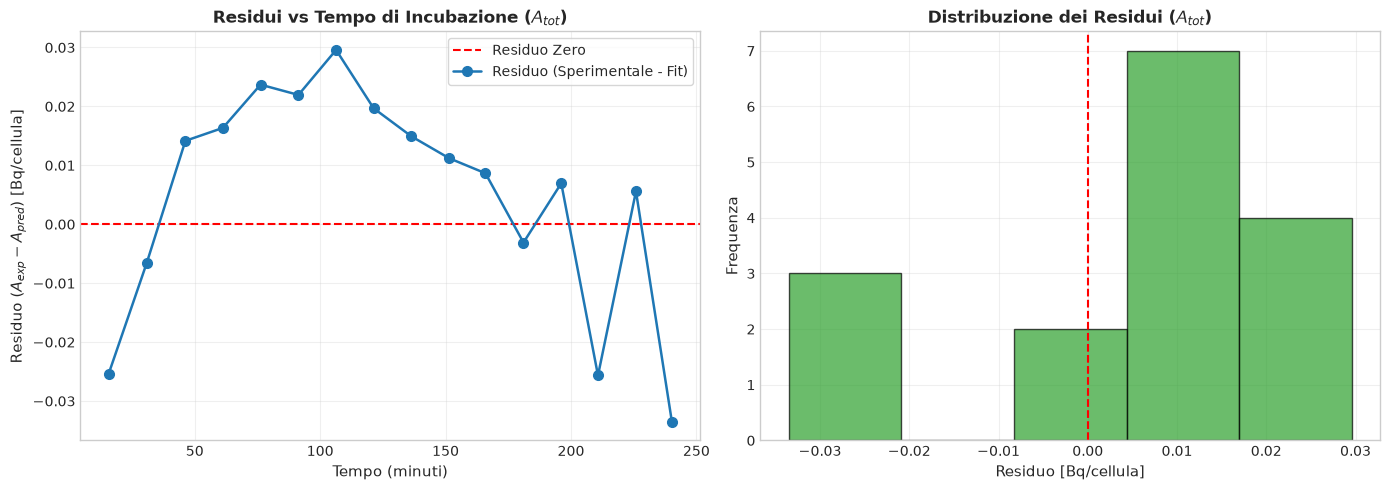

--------------------------------------------------
          STATISTICA DEI RESIDUI DEL FIT          
--------------------------------------------------
Media dei residui       : 4.900919e-03 Bq/cellula (ideale: ~0)
Deviazione Standard     : 1.832583e-02 Bq/cellula
Massimo errore assoluto : 3.353009e-02 Bq/cellula
--------------------------------------------------


In [108]:
# =============================================================================
# ANALISI DEI RESIDUI PER L'ATTIVITÀ TOTALE
# =============================================================================

# 1. Calcolo delle predizioni sui punti sperimentali e dei residui
_, preds_tot_exp = solve_ode_system(res_fit.x, t_exp_tot, A0_val)
residuals_val = y_tot_exp - preds_tot_exp

# 2. Creazione della figura con 2 grafici affiancati
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grafico A: Residui vs Tempo (in minuti)
axes[0].axhline(0, color='red', linestyle='--', linewidth=1.5, label='Residuo Zero')
axes[0].plot(t_min_tot, residuals_val, 'o-', color='#1f77b4', markersize=7, linewidth=1.8, label='Residuo (Sperimentale - Fit)')
axes[0].set_title('Residui vs Tempo di Incubazione ($A_{tot}$)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Tempo (minuti)', fontsize=11)
axes[0].set_ylabel('Residuo ($A_{exp} - A_{pred}$) [Bq/cellula]', fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].legend(frameon=True, fontsize=10)

# Grafico B: Istogramma della distribuzione dei residui
axes[1].hist(residuals_val, bins='auto', color='#2ca02c', edgecolor='black', alpha=0.7)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_title('Distribuzione dei Residui ($A_{tot}$)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Residuo [Bq/cellula]', fontsize=11)
axes[1].set_ylabel('Frequenza', fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 3. Metriche sintetiche della qualità del fit
print("--------------------------------------------------")
print("          STATISTICA DEI RESIDUI DEL FIT          ")
print("--------------------------------------------------")
print(f"Media dei residui       : {np.mean(residuals_val):.6e} Bq/cellula (ideale: ~0)")
print(f"Deviazione Standard     : {np.std(residuals_val):.6e} Bq/cellula")
print(f"Massimo errore assoluto : {np.max(np.abs(residuals_val)):.6e} Bq/cellula")
print("--------------------------------------------------")